# 🧪 Notebook 05: Differential Expression Analysis (DEA) using Python

## 🎯 Introduction
Now that we have generated our raw counts matrix (`raw_counts.txt`), we will perform Differential Expression Analysis (DEA) to identify which genes are significantly up-regulated or down-regulated in response to the drug treatment.

### Objectives for this Notebook:
1. Load and clean the `raw_counts.txt` matrix using `pandas`.
2. Define the Experimental Design (Metadata/Design Matrix).
3. Perform Exploratory Data Analysis (EDA) using PCA (Principal Component Analysis) to check sample clustering.
4. Run Differential Expression Analysis (using PyDESeq2 or statistical libraries).
5. Visualize the results using a **Volcano Plot** and a **Heatmap**.

In [5]:
import pandas as pd
import numpy as np

# 1. Load the raw counts matrix (skip the first metadata line from featureCounts)
df = pd.read_csv('results/count_matrix/raw_counts.txt', sep='\t', skiprows=1)

# 2. Clean column names to keep only the Sample ID (SRRXXXXXXXX)
clean_columns = {}
for col in df.columns:
    if 'SRR' in col:
        sample_id = col.split('/')[-1].split('_')[0]
        clean_columns[col] = sample_id

df.rename(columns=clean_columns, inplace=True)

# 3. Separate Gene info and Transpose the matrix for PyDESeq2 (Samples must be rows)
df.set_index('Geneid', inplace=True)
sample_cols = ['SRR32812560', 'SRR32812561', 'SRR32812562', 'SRR32812566', 'SRR32812567', 'SRR32812572']
count_matrix = df[sample_cols].T  

# 4. Create the Metadata DataFrame mapping samples to conditions
metadata = pd.DataFrame({
    'Condition': ['Treated', 'Treated', 'Treated', 'Untreated', 'Untreated', 'Untreated']
}, index=sample_cols)

# Verify the alignment
print("🔍 --- METADATA MATRIX ---")
print(metadata)
print("\n📊 --- COUNT MATRIX PREVIEW (First 5 genes) ---")
print(count_matrix.iloc[:, :5])

🔍 --- METADATA MATRIX ---
             Condition
SRR32812560    Treated
SRR32812561    Treated
SRR32812562    Treated
SRR32812566  Untreated
SRR32812567  Untreated
SRR32812572  Untreated

📊 --- COUNT MATRIX PREVIEW (First 5 genes) ---
Geneid       Rv0001  Rv0002  Rv0003  Rv0004  Rv0005
SRR32812560    7532    1451    1369    1170   41122
SRR32812561    8810    1406    1441    1033   42873
SRR32812562    6224    1110    1182     830   29911
SRR32812566    6876    1374    1281    1068   34445
SRR32812567    5257     980     920     778   27490
SRR32812572    9864    1928    2190    1628   53080


## 📊 Step 2: Pre-filtering & Exploratory Data Analysis (PCA)

Before running the full differential expression model, we need to:
1. **Filter out low-count genes:** Genes with very low reads across all samples add noise and slow down calculations.
2. **Normalize the data:** Adjust for differences in sequencing depth using PyDESeq2's Size Factors.
3. **Perform PCA (Principal Component Analysis):** Visualize sample clustering to ensure biological replicates group together and conditions clearly separate.

✂️ Original genes: 3978
🧬 Remaining genes after filtering: 3964
Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_1395/4053325546.py:13: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

/home/azureuser/miniconda3/envs/transcriptomics_env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


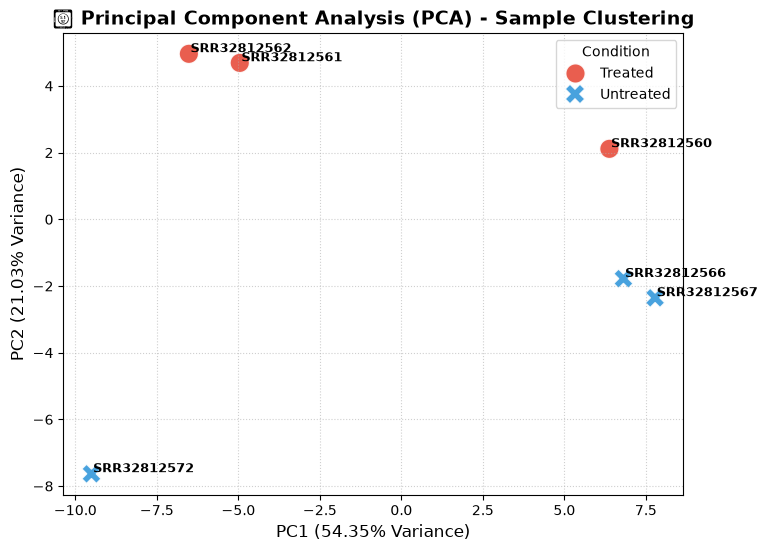

In [7]:
from pydeseq2.dds import DeseqDataSet
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pre-filtering: Keep genes with a total sum of 10 or more reads across all 6 samples
genes_to_keep = count_matrix.columns[count_matrix.sum(axis=0) >= 10]
filtered_counts = count_matrix[genes_to_keep]
print(f"✂️ Original genes: {count_matrix.shape[1]}")
print(f"🧬 Remaining genes after filtering: {filtered_counts.shape[1]}")

# 2. Initialize DeseqDataSet to estimate Size Factors for normalization
dds = DeseqDataSet(
    counts=filtered_counts,
    metadata=metadata,
    design_factors="Condition"
)
dds.fit_size_factors()

normalized_counts = filtered_counts.div(dds.obs['size_factors'], axis=0)
log_counts = np.log2(normalized_counts + 1)

# 3. Compute PCA (reducing dimensions to PC1 and PC2)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(log_counts)
var_exp = pca.explained_variance_ratio_ * 100  # Percentage of variance explained

# Create a clean DataFrame for plotting
pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'], index=count_matrix.index)
pca_df['Condition'] = metadata['Condition']

# 4. Plot the PCA
plt.figure(figsize=(8, 6))
colors = {'Treated': '#e74c3c', 'Untreated': '#3498db'} # Red for Treated, Blue for Untreated

sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Condition', style='Condition',
    s=200, palette=colors, alpha=0.9
)

# Label each point with its Sample ID (SRR...)
for sample in pca_df.index:
    plt.text(pca_df.loc[sample, 'PC1'] + 0.05, pca_df.loc[sample, 'PC2'] + 0.05, sample, fontsize=9, weight='bold')

plt.title('🧬 Principal Component Analysis (PCA) - Sample Clustering', fontsize=14, weight='bold')
plt.xlabel(f'PC1 ({var_exp[0]:.2f}% Variance)', fontsize=12)
plt.ylabel(f'PC2 ({var_exp[1]:.2f}% Variance)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 🚀 Step 3: Full Differential Expression Analysis (DEA)

With our sample clustering validated via PCA, we proceed to fit the full Negative Binomial generalized linear model (GLM) using PyDESeq2. This step estimates gene-wise dispersions and performs the Wald test to determine statistically significant changes in gene expression between the `Treated` and `Untreated` groups.

### Statistical Cut-offs Applied:
* **Significance Threshold:** Adjusted p-value (`padj`) $< 0.05$ (Benjamini-Hochberg correction).
* **Biological Magnitude:** $|\text{Log2 Fold Change}| > 0.5$ (representing an approximate 1.5-fold change in expression).

In [9]:
from pydeseq2.ds import DeseqStats
import os

print("⏳ Extracting statistical results using summary()...")

# 1. Run the Wald test and calculate p-values using the correct method for recent versions
stat_res = DeseqStats(dds, contrast=["Condition", "Treated", "Untreated"])
stat_res.summary()  # Computes p-values and generates the results table
res_df = stat_res.results_df  # Securely extract the results DataFrame

# 2. Define biological and statistical thresholds
padj_thresh = 0.05
lfc_thresh = 0.5

# 3. Filter significantly up-regulated and down-regulated genes
up_genes = res_df[(res_df['padj'] < padj_thresh) & (res_df['log2FoldChange'] > lfc_thresh)]
down_genes = res_df[(res_df['padj'] < padj_thresh) & (res_df['log2FoldChange'] < -lfc_thresh)]

print("\n📊 --- FINAL STATISTICAL FILTERING RESULTS ---")
print(f"📈 Significantly Up-regulated genes: {len(up_genes)}")
print(f"📉 Significantly Down-regulated genes: {len(down_genes)}")
print(f"🧬 Total Differentially Expressed Genes (DEGs): {len(up_genes) + len(down_genes)}")

# 4. Save significant gene lists to the results directory
os.makedirs('results/count_matrix', exist_ok=True)
up_genes.to_csv('results/count_matrix/significant_up_genes.csv')
down_genes.to_csv('results/count_matrix/significant_down_genes.csv')
print("\n💾 Saved significant genes lists to 'results/count_matrix/'")

⏳ Extracting statistical results using summary()...


Running Wald tests...


Log2 fold change & Wald test p-value: Condition Treated vs Untreated
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Geneid                                                                       
Rv0001    7277.039934        0.024338  0.101664  0.239396  0.810798  0.992520
Rv0002    1344.594037       -0.119836  0.084496 -1.418244  0.156119  0.913816
Rv0003    1356.628072       -0.112011  0.144015 -0.777777  0.436701  0.990155
Rv0004    1055.957283       -0.199907  0.105837 -1.888826  0.058915  0.755962
Rv0005   37236.182366       -0.028418  0.093571 -0.303701  0.761356  0.990736
...               ...             ...       ...       ...       ...       ...
Rv3920c   5597.329955       -0.218082  0.096062 -2.270230  0.023194  0.558011
Rv3921c   9054.962451       -0.128036  0.081901 -1.563303  0.117981  0.898709
Rv3922c   1380.210592       -0.085662  0.115809 -0.739679  0.459495  0.990155
Rv3923c   2179.795132        0.135269  0.102612  1.318256  0.187418  0.94

... done in 2.75 seconds.



## 🌋 Step 4: Data Visualization - Volcano Plot

To globally visualize the distribution of our differential expression analysis results, we will construct a **Volcano Plot**. 
This scatter plot displays the statistical significance ($- \log_{10}$ of the Adjusted P-value) on the Y-axis against the biological magnitude of change ($\log_{2}$ Fold Change) on the X-axis. 

Highly significant Differentially Expressed Genes (DEGs) will appear in the top-left (Down-regulated) and top-right (Up-regulated) quadrants.

<>:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:50: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:50: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_1395/470083884.py:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('$\log_{2}$ Fold Change (Treated / Untreated)', fontsize=11)
/tmp/ipykernel_1395/470083884.py:50: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the fu

🌋 Generating high-resolution Volcano Plot...
🎉 Plot successfully rendered and saved to: results/count_matrix/volcano_plot.png


/home/azureuser/miniconda3/envs/transcriptomics_env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


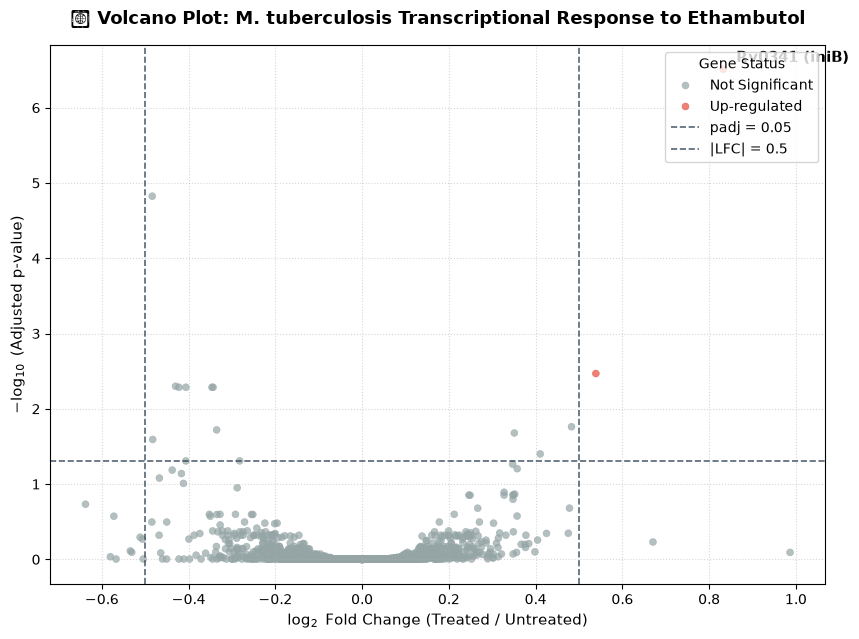

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🌋 Generating high-resolution Volcano Plot...")

# 1. Create a copy of the results for visualization and handle padj = 0 to avoid log10 errors
plot_df = res_df.copy().dropna(subset=['pvalue', 'padj'])
plot_df['-log10_padj'] = -np.log10(plot_df['padj'].replace(0, 1e-15))

# 2. Categorize genes into Up-regulated, Down-regulated, or Not Significant
plot_df['Expression'] = 'Not Significant'
plot_df.loc[(plot_df['padj'] < padj_thresh) & (plot_df['log2FoldChange'] > lfc_thresh), 'Expression'] = 'Up-regulated'
plot_df.loc[(plot_df['padj'] < padj_thresh) & (plot_df['log2FoldChange'] < -lfc_thresh), 'Expression'] = 'Down-regulated'

# 3. Setup the plotting canvas
plt.figure(figsize=(10, 7), dpi=100)
colors = {'Not Significant': '#95a5a6', 'Up-regulated': '#e74c3c', 'Down-regulated': '#3498db'}

# Scatter plot for all genes
sns.scatterplot(
    data=plot_df, 
    x='log2FoldChange', 
    y='-log10_padj', 
    hue='Expression', 
    palette=colors, 
    alpha=0.7, 
    edgecolor=None,
    s=25
)

# 4. Add threshold cut-off lines
plt.axhline(-np.log10(padj_thresh), color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.8, label=f'padj = {padj_thresh}')
plt.axvline(lfc_thresh, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.8, label=f'|LFC| = {lfc_thresh}')
plt.axvline(-lfc_thresh, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.8)

# 5. Label the top up-regulated biomarker (Rv0341) if present in the data
top_gene = 'Rv0341'
if top_gene in plot_df.index:
    plt.text(
        plot_df.loc[top_gene, 'log2FoldChange'] + 0.03, 
        plot_df.loc[top_gene, '-log10_padj'] + 0.1, 
        f"{top_gene} (iniB)", 
        fontsize=11, weight='bold', color='black'
    )

# 6. Adjust figure details and aesthetics
plt.title('🌋 Volcano Plot: M. tuberculosis Transcriptional Response to Ethambutol', fontsize=13, weight='bold', pad=15)
plt.xlabel('$\log_{2}$ Fold Change (Treated / Untreated)', fontsize=11)
plt.ylabel('$-\log_{10}$ (Adjusted p-value)', fontsize=11)
plt.legend(title='Gene Status', loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

# 7. Save the figure locally
output_path = 'results/count_matrix/volcano_plot.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"🎉 Plot successfully rendered and saved to: {output_path}")

# Show plot inside the notebook
plt.show()

## 🔥 Step 5: Data Visualization - Expression Heatmap

To visualize the expression patterns across individual samples, we will generate a hierarchical clustering **Heatmap**. 
Since we have a limited number of strictly significant DEGs, we will plot the **Top 20 genes** with the lowest adjusted p-values. 

The counts are $\log_{2}$ transformed and row-scaled (Z-score) to highlight relative expression changes (up-regulation in warm colors, down-regulation in cool colors) between the `Treated` and `Untreated` groups.

🔥 Generating Expression Heatmap for top 20 genes...


/home/azureuser/miniconda3/envs/transcriptomics_env/lib/python3.14/site-packages/seaborn/axisgrid.py:100: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  self.figure.savefig(*args, **kwargs)


🎉 Heatmap successfully rendered and saved to: results/count_matrix/heatmap_top20.png


/home/azureuser/miniconda3/envs/transcriptomics_env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


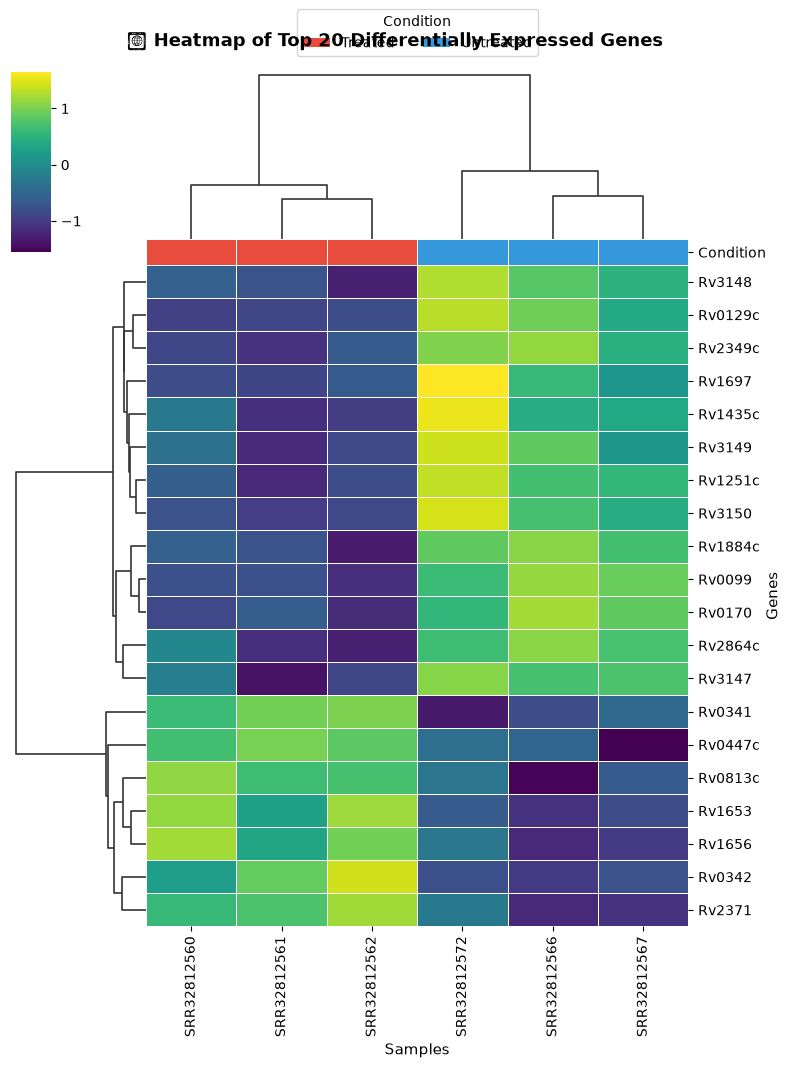

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

print("🔥 Generating Expression Heatmap for top 20 genes...")

# 1. Select the top 20 most differentially expressed genes (by lowest padj)
top_genes = res_df.sort_values('padj').head(20).index

# 2. Extract their log-normalized counts 
# (Select columns since genes are columns, then Transpose .T to make genes as rows)
heatmap_data = log_counts[top_genes].T

# 3. Create a color map for the conditions to display as a top track
condition_colors = metadata['Condition'].map({'Treated': '#e74c3c', 'Untreated': '#3498db'})

# 4. Generate the Clustermap (Heatmap with hierarchical clustering)
g = sns.clustermap(
    heatmap_data,
    cmap='viridis',       # Color palette (dark/purple for low, yellow for high)
    z_score=0,            # Standardize by rows (genes) to see relative changes clearly
    col_colors=condition_colors, # Add the Treatment/Untreated color bar on top
    figsize=(8, 10),
    linewidths=0.5,
    cbar_pos=(0.02, 0.8, 0.05, 0.18), # Position of the color legend
    tree_kws={'linewidths': 1.2}
)

# 5. Adjust aesthetics and labels
g.fig.suptitle('🔥 Heatmap of Top 20 Differentially Expressed Genes', y=1.02, fontsize=13, weight='bold')
g.ax_heatmap.set_xlabel('Samples', fontsize=11)
g.ax_heatmap.set_ylabel('Genes', fontsize=11)

# Add a manual legend for the condition colors
for condition, color in {'Treated': '#e74c3c', 'Untreated': '#3498db'}.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=condition, linewidth=0)
g.ax_col_dendrogram.legend(title='Condition', loc="center", ncol=2, bbox_to_anchor=(0.5, 1.2))

# 6. Save the figure locally
output_path = 'results/count_matrix/heatmap_top20.png'
g.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"🎉 Heatmap successfully rendered and saved to: {output_path}")

# Show plot inside the notebook
plt.show()